In [4]:
!pip install onnxruntime numpy onnx

  Using cached onnxruntime-1.25.1-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached onnx-1.21.0-cp312-abi3-win_amd64.whl.metadata (8.7 kB)
Using cached onnxruntime-1.25.1-cp313-cp313-win_amd64.whl (12.9 MB)
Using cached onnx-1.21.0-cp312-abi3-win_amd64.whl (16.4 MB)

   ---------------------------------------- 0/2 [onnxruntime]
   ---------------------------------------- 0/2 [onnxruntime]
   ---------------------------------------- 0/2 [onnxruntime]
   ---------------------------------------- 0/2 [onnxruntime]
   ---------------------------------------- 0/2 [onnxruntime]
   ---------------------------------------- 0/2 [onnxruntime]
   ---------------------------------------- 0/2 [onnxruntime]
   ---------------------------------------- 0/2 [onnxruntime]
   ---------------------------------------- 0/2 [onnxruntime]
   ---------------------------------------- 0/2 [onnxruntime]
   ---------------------------------------- 0/2 [onnxruntime]
   --------------------------------------

In [21]:
import os
import time
import onnxruntime as ort
import numpy as np
from PIL import Image
from pathlib import Path

# --- CLASSIFICATION LABELS ---
AUTH_CLASSES = ["real", "fake"]
TUMOR_CLASSES = ["no_tumor", "glioma", "meningioma", "pituitary"]

# 1. Define paths
model_path = r"D:\Semester 6\ANN\Project\AbuzarWork\LightWeight\Submission_Files\Code_Files\EPIC&CSRMendly\multitask_mri.onnx"
# Define the root directory containing your subfolders ('real' and 'fake')
images_dir = r"D:\Semester 6\ANN\Project\AbuzarWork\LightWeight\Submission_Files\Code_Files\InferenceFiles"

# 2. Image Preprocessing Setup
IMAGE_SIZE = 224

def preprocess_image_clean(img_path, target_size=(224, 224)):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(target_size, Image.Resampling.BILINEAR)
    img_array = np.array(img, dtype=np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_array = (img_array - mean) / std
    img_array = np.transpose(img_array, (2, 0, 1))
    img_array = np.expand_dims(img_array, axis=0) # shape (1, 3, H, W)
    return img_array

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / e_x.sum(axis=1, keepdims=True)

# 3. Initialize Inference Session
print(f"\nLoading ONNX model from: {model_path}")
sess_options = ort.SessionOptions()
session = ort.InferenceSession(model_path, sess_options, providers=['CPUExecutionProvider'])

input_name = session.get_inputs()[0].name
output_names = [o.name for o in session.get_outputs()]

# 4. Get all images recursively in the directory (including subfolders)
valid_extensions = {".png", ".jpg", ".jpeg"}
image_paths = [p for p in Path(images_dir).rglob("*") if p.suffix.lower() in valid_extensions]

# Initialize a list to hold the results for visualization
inference_results = []

if not image_paths:
    print(f"No images found in directory or subdirectories of: {images_dir}")
else:
    print(f"\nFound {len(image_paths)} images in {images_dir} and its subfolders. Starting batch inference...\n")
    print("-" * 75)
    
    total_time = 0.0

    # 5. Run Inference loop
    for img_path in image_paths:
        try:
            # Preprocess
            input_data = preprocess_image_clean(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
            
            # Start timer
            start_time = time.perf_counter()
            
            # Inference
            results = session.run(output_names, {input_name: input_data})
            
            # End timer
            end_time = time.perf_counter()
            inference_time_ms = (end_time - start_time) * 1000
            total_time += inference_time_ms
            
            auth_logits, tumor_logits = results[0], results[1]
            
            auth_probs = softmax(auth_logits)
            tumor_probs = softmax(tumor_logits)
            
            auth_pred_idx = np.argmax(auth_probs[0])
            tumor_pred_idx = np.argmax(tumor_probs[0])
            
            predicted_auth = AUTH_CLASSES[auth_pred_idx]
            predicted_tumor = TUMOR_CLASSES[tumor_pred_idx]
            
            parent_folder = img_path.parent.name
            
            # Store the data for our visualizer
            inference_results.append({
                "filename": img_path.name,
                "folder": parent_folder,
                "auth": predicted_auth,
                "tumor": predicted_tumor,
                "auth_confidence": auth_probs[0][auth_pred_idx],
                "tumor_confidence": tumor_probs[0][tumor_pred_idx]
            })
            
            # Display results
            print(f"File: {parent_folder}/{img_path.name}")
            print(f"  Time: {inference_time_ms:.2f} ms")
            print(f"  Auth: {predicted_auth.upper()} ({auth_probs[0][auth_pred_idx]*100:.1f}%)")
            
            if predicted_auth == "fake":
                 print(f"  Tumor: {predicted_tumor.upper()} (Ignored mostly for fakes)")
            else:
                 print(f"  Tumor: {predicted_tumor.upper()} ({tumor_probs[0][tumor_pred_idx]*100:.1f}%)")
            print("-" * 75)
            
        except Exception as e:
            print(f"Error processing {img_path.name}: {e}")
            print("-" * 75)

    print(f"\nBatch Inference Complete.")
    print(f"Average Inference Time per Image: {total_time / len(image_paths):.2f} ms")


Loading ONNX model from: D:\Semester 6\ANN\Project\AbuzarWork\LightWeight\Submission_Files\Code_Files\EPIC&CSRMendly\multitask_mri.onnx

Found 22 images in D:\Semester 6\ANN\Project\AbuzarWork\LightWeight\Submission_Files\Code_Files\InferenceFiles and its subfolders. Starting batch inference...

---------------------------------------------------------------------------
File: fake/glioma_00001.png
  Time: 4.57 ms
  Auth: FAKE (95.3%)
  Tumor: GLIOMA (Ignored mostly for fakes)
---------------------------------------------------------------------------
File: fake/glioma_00001_test.png
  Time: 7.42 ms
  Auth: FAKE (74.0%)
  Tumor: GLIOMA (Ignored mostly for fakes)
---------------------------------------------------------------------------
File: fake/glioma_00002.png
  Time: 3.34 ms
  Auth: FAKE (94.4%)
  Tumor: GLIOMA (Ignored mostly for fakes)
---------------------------------------------------------------------------
File: fake/meningioma_000.png
  Time: 3.94 ms
  Auth: FAKE (85.6%)
  

C:\Users\REHAN\AppData\Local\Temp\ipykernel_10688\2538846035.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='auth', ax=axes[0], palette=['#4CAF50', '#E53935'], order=['real', 'fake'])
C:\Users\REHAN\AppData\Local\Temp\ipykernel_10688\2538846035.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tumors, x='tumor', ax=axes[1], palette='Set2', order=["no_tumor", "glioma", "meningioma", "pituitary"])


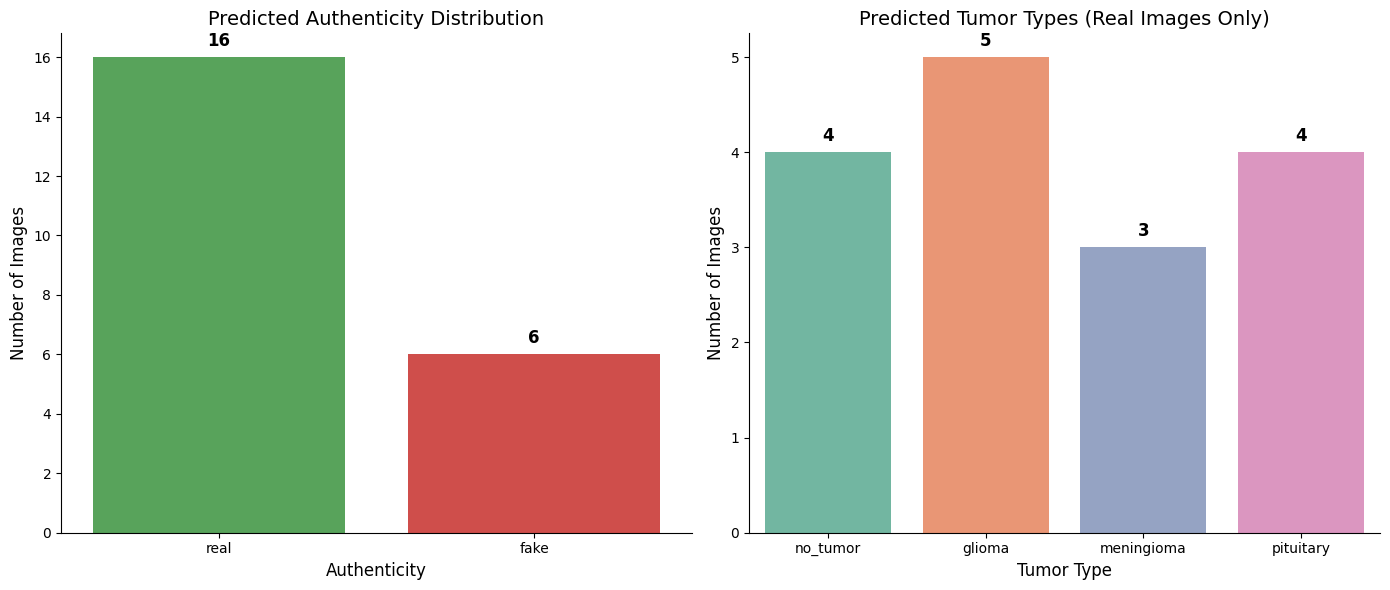

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Check if there are any results to visualize
if 'inference_results' in globals() and len(inference_results) > 0:
    df = pd.DataFrame(inference_results)
    
    # Create the visualization figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- 1. Authenticity Plot ---
    sns.countplot(data=df, x='auth', ax=axes[0], palette=['#4CAF50', '#E53935'], order=['real', 'fake'])
    axes[0].set_title('Predicted Authenticity Distribution', fontsize=14)
    axes[0].set_xlabel('Authenticity', fontsize=12)
    axes[0].set_ylabel('Number of Images', fontsize=12)
    
    # Add count labels on top of the bars
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')
                         
    # --- 2. Tumor Type Plot ---
    # Only include images predicted as 'real' for tumor calculation
    df_tumors = df[df['auth'] == 'real']
    
    sns.countplot(data=df_tumors, x='tumor', ax=axes[1], palette='Set2', order=["no_tumor", "glioma", "meningioma", "pituitary"])
    axes[1].set_title('Predicted Tumor Types (Real Images Only)', fontsize=14)
    axes[1].set_xlabel('Tumor Type', fontsize=12)
    axes[1].set_ylabel('Number of Images', fontsize=12)
    
    for p in axes[1].patches:
        axes[1].annotate(f'{int(p.get_height())}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

    # Display plots
    sns.despine()
    plt.tight_layout()
    plt.show()

else:
    print("No inference results found. Run the inference cell first!")